In [1]:
import tifffile as tiff
import numpy as np  
import  matplotlib.pyplot as plt
import cv2

In [2]:
img = tiff.imread('C:\\Users\\Fabagh001\\Desktop\\B51_bag01_hxfb101ms_block_0_117.tif')
print (img.shape)
print (img.dtype)
print (img.max())
print (img.min())


(8352, 992, 992)
uint8
1
0


In [3]:
img = tiff.imread('C:\\Users\\Fabagh001\\Desktop\\check for weight issue\\B51_bag02_hxfb101ms_block_0.tif')
print (img.shape)
print (img.dtype)

(8292, 992, 992)
uint8


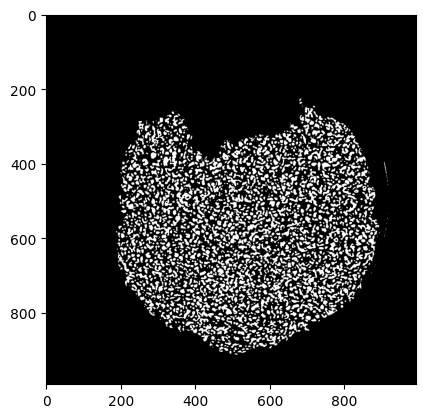

In [7]:
plt.imshow(img[4999,:,:], cmap='gray')

In [19]:
img[100,:,:].max()

1

In [29]:
ice_part = get_ice_part(img[100:200,:,:],100)
sample = set_sample_volume(img[100:200,:,:], ice_part)

center =  (51.4223424065017, 532.8528497199385, 509.35531728656093)
bounds =  459 559 482 582


(100, 100, 100)
uint8
1
0


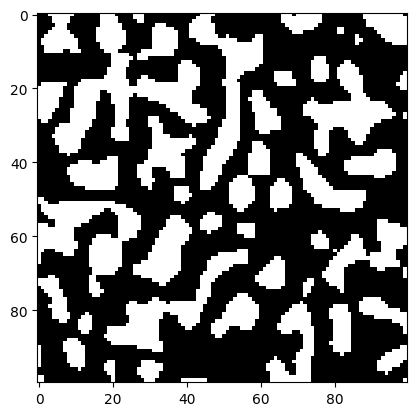

In [35]:
print (sample.shape)
print (sample.dtype)
print (sample.max())
print (sample.min())
plt.imshow(sample[50,:,:], cmap='gray')

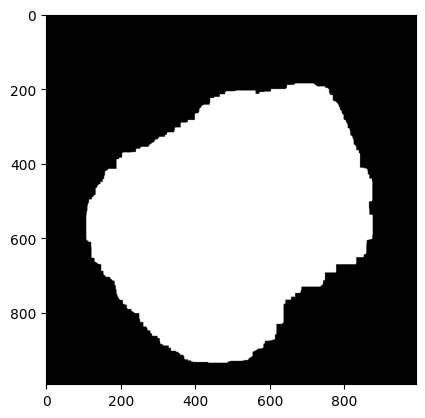

In [26]:
plt.imshow(ice_part[0,:,:], cmap='gray')

In [24]:
def get_ice_part(data,depth):
    """
    data is a binary 3d image
    kernel_size_dilute = 2 for bubble ice
    kernel_size_dilute = 20 for compressed snow
    """
    if depth < 80:
        kernel_size_dilute=80
    else:
        kernel_size_dilute=50

    mask = np.zeros_like(data)
    kernel_dilute = np.ones((kernel_size_dilute,kernel_size_dilute),np.uint8)

    for i in range(data.shape[0]):
        an_img = data[i]
        a_mask = np.zeros_like(an_img)
        diluted = cv2.dilate(an_img,kernel_dilute,iterations = 1)
        contours, _ = cv2.findContours(diluted, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contours = sorted(contours, key=lambda x: cv2.contourArea(x), reverse=True)

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area > 10:  # Adjust this threshold based on the size of the ice pieces
                cv2.drawContours(a_mask, [cnt], -1, 1, thickness=-1)

        mask[i] = a_mask
    return mask

In [28]:
def set_sample_volume(data, ice_mask):
    from skimage.measure import label, regionprops
    #cropping x and y assuming z is already cropped by the sample maker

    if ice_mask.shape != data.shape:
        raise ValueError("The shape of the ice mask does not match the shape of the data.")

    half_edge = int(data.shape[0] / 2)

    try:
        rg = regionprops (ice_mask.astype('uint8'))
        center = rg[0].centroid
    except:
        center = tuple((np.array(data.shape) // 2).astype(int))

    x_start = int( center[2] - half_edge)
    x_end = int(center[2] + half_edge )

    y_start = int(center[1] - half_edge)
    y_end = int(center[1] + half_edge )

    print ('center = ',center)
    print ('bounds = ',x_start,x_end,y_start,y_end)

    sample = data[:, y_start:y_end, x_start:x_end] 

    return sample

In [44]:
img1[7800, :, :].max()

1